# Pyomo Übung 1

### Optimierung im landwirtschaftlichen Betrieb
Eine Landwirtin hat eine Ackerfläche von 1 Hektar zur Verfügung. Auf dieser Fläche sollen Energiepflanzen angebaut werden. Die Landwirtin will Mais für die Biomethan-Herstellung und Zuckerrüben für die Biokraftstoff-Herstellung anbauen, wobei sich nur 6.000 m2 der Gesamtfläche für den Anbau von Zuckerrüben eignet. Welche Fläche sollte Sie wie bepflanzen um ihren Profit zu maximieren?

Die Bestellung eines Hektars Mais kostet 1.500 €. Die eines Hektars Zuckerrüben 2.000 €.
Durch den Biomethan- bzw. Bioethanolpreis, der Effizienz der Vergärung und der Energiedichte der Pflanzen kann man die Erlöse mit 0,25 € je m2 Mais und 0,40 € je m2 Zuckerrüben annehmen.
Zum aktuellen Zeitpunkt steht der Landwirtin ein Kapital von 1650 € für diesen Hektar zur Verfügung.

Importieren Sie das Modul "environ" der Bibliothekt "pyomo":
"import pyomo.environ as pyo"

In [2]:
import pyomo.environ as pyo

Erstellen Sie nun das Modell und benennen Sie dieses

In [7]:
model_landwirtschaft = pyo.ConcreteModel(name = 'Energiepflanzen') 

Parametrisieren Sie nun Ihr Modell

In [8]:
model_landwirtschaft.Feld_Groesse = pyo.Param(initialize = 10000, 
                                              name = 'Größe d. Feldes in m^2')
model_landwirtschaft.Max_Zuckerrueben = pyo.Param(initialize = 6000,
                                                  name = 'Max. Fläche für Zuckerrüben in m^2')
model_landwirtschaft.Kosten_Mais           = pyo.Param(initialize = 1500/10000, name='Kosten für Mais in €/m^2')
model_landwirtschaft.Kosten_Zuckerrueben   = pyo.Param(initialize = 2000/10000, name='Kosten für Zuckerrüben in €/m^2')
model_landwirtschaft.Erloes_Mais           = pyo.Param(initialize = 0.25,       name='Erlös Mais in €/m^2')
model_landwirtschaft.Erloes_Zuckerrueben   = pyo.Param(initialize = 0.40,       name='Erlös Zuckerrueben in €/m^2')
model_landwirtschaft.Kapital               = pyo.Param(initialize = 1650,       name='Kapital in €')

Fügen Sie nun die Variablen hinzu

In [9]:
model_landwirtschaft.A_Mais                = pyo.Var( within=pyo.NonNegativeReals) #Fläche Mais in m2
model_landwirtschaft.A_Zuckerrueben         = pyo.Var(within=pyo.NonNegativeReals) #Fläche Zuckerrüben in m2

Erstellen Sie nun die Zielfunktion

In [10]:
model_landwirtschaft.obj = pyo.Objective(expr = model_landwirtschaft.A_Mais  * (model_landwirtschaft.Erloes_Mais - model_landwirtschaft.Kosten_Mais) + model_landwirtschaft.A_Zuckerrueben * (model_landwirtschaft.Erloes_Zuckerrueben - model_landwirtschaft.Kosten_Zuckerrueben), 
                      sense = pyo.maximize)

Fügen Sie nun die Nebenbedingungen hinzu

In [11]:
model_landwirtschaft.con_feldgroesse       = pyo.Constraint(expr = model_landwirtschaft.A_Mais + model_landwirtschaft.A_Zuckerrueben <= model_landwirtschaft.Feld_Groesse, 
                                         name='Feldgröße')
model_landwirtschaft.con_zuckergroesse     = pyo.Constraint(expr = model_landwirtschaft.A_Zuckerrueben <= model_landwirtschaft.Max_Zuckerrueben, 
                                         name='Zuckerruebengöße')
model_landwirtschaft.con_invest            = pyo.Constraint(expr = model_landwirtschaft.A_Mais * model_landwirtschaft.Kosten_Mais + model_landwirtschaft.A_Zuckerrueben * model_landwirtschaft.Kosten_Zuckerrueben <= model_landwirtschaft.Kapital,
                                         name='Maximaler Invest')

Lösen Sie das Modell

In [12]:
solver = pyo.SolverFactory('cbc')
solver.solve(model_landwirtschaft)

{'Problem': [{'Name': 'unknown', 'Lower bound': 1500.0, 'Upper bound': 1500.0, 'Number of objectives': 1, 'Number of constraints': 3, 'Number of variables': 2, 'Number of nonzeros': 2, 'Sense': 'maximize'}], 'Solver': [{'Status': 'ok', 'User time': -1.0, 'System time': 0.01, 'Wallclock time': 0.0, 'Termination condition': 'optimal', 'Termination message': 'Model was solved to optimality (subject to tolerances), and an optimal solution is available.', 'Statistics': {'Branch and bound': {'Number of bounded subproblems': None, 'Number of created subproblems': None}, 'Black box': {'Number of iterations': 2}}, 'Error rc': 0, 'Time': 0.024698257446289062}], 'Solution': [OrderedDict({'number of solutions': 0, 'number of solutions displayed': 0})]}

Lassen Sie sich die Flächen für Mais und Zuckerrüben, sowie den Erlös und den Gewinn ausgeben

In [13]:
print("Mais:",round(model_landwirtschaft.A_Mais.value,2),"m^2")
print("Zuckerrüben:",round(model_landwirtschaft.A_Zuckerrueben.value,2),"m^2")
print("Erlös:",round(model_landwirtschaft.A_Mais.value*model_landwirtschaft.Erloes_Mais.value+model_landwirtschaft.A_Zuckerrueben.value*model_landwirtschaft.Erloes_Zuckerrueben.value,2),"€")
print("Gewinn:",round(model_landwirtschaft.obj(),2),"€")

Mais: 3000.0 m^2
Zuckerrüben: 6000.0 m^2
Erlös: 3150.0 €
Gewinn: 1500.0 €


In [16]:
model_landwirtschaft.display()

Model Energiepflanzen

  Variables:
    A_Mais : Size=1, Index=None
        Key  : Lower : Value  : Upper : Fixed : Stale : Domain
        None :     0 : 3000.0 :  None : False : False : NonNegativeReals
    A_Zuckerrueben : Size=1, Index=None
        Key  : Lower : Value  : Upper : Fixed : Stale : Domain
        None :     0 : 6000.0 :  None : False : False : NonNegativeReals

  Objectives:
    obj : Size=1, Index=None, Active=True
        Key  : Active : Value
        None :   True : 1500.0

  Constraints:
    con_feldgroesse : Size=1
        Key  : Lower : Body   : Upper
        None :  None : 9000.0 : 10000.0
    con_zuckergroesse : Size=1
        Key  : Lower : Body   : Upper
        None :  None : 6000.0 : 6000.0
    con_invest : Size=1
        Key  : Lower : Body   : Upper
        None :  None : 1650.0 : 1650.0


Optional: Stellen Sie den Lösungsraum und die Randbedingungen grafisch dar, variieren Sie dann die Eingangsparameter und beobachten Sie die Auswirkungen auf den Lösungsraum und die optimale Lösung.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

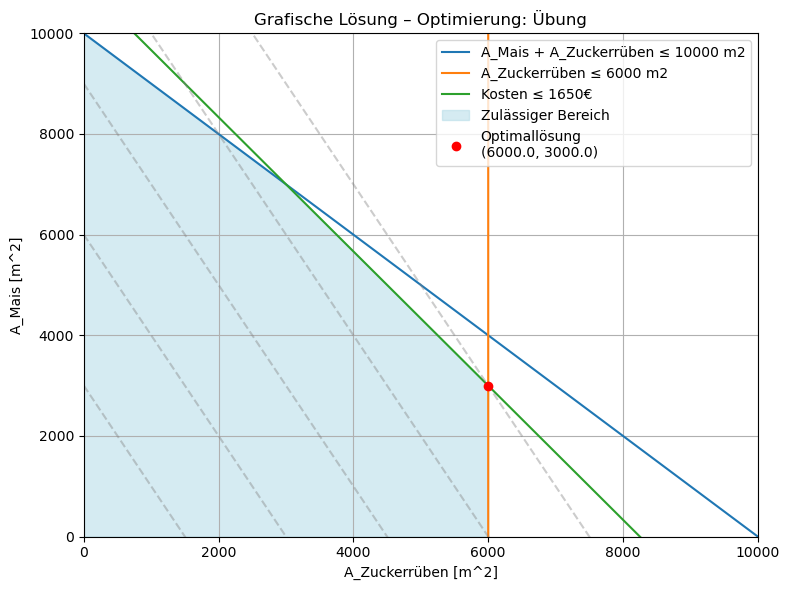

In [17]:
# Ergebnis auslesen
x_opt =  model_landwirtschaft.A_Zuckerrueben.value
y_opt =  model_landwirtschaft.A_Mais.value


# ----------- Plot -----------

x = np.linspace(0, model_landwirtschaft.Feld_Groesse.value, num = model_landwirtschaft.Feld_Groesse.value)

# Restriktionen umstellen: A_M = ...
y1 = model_landwirtschaft.Feld_Groesse.value - x                    # aus A_M + A_Z <= 10000 → A_M = 10000 - A_Z
y2 = np.full_like(x, model_landwirtschaft.Max_Zuckerrueben.value)  # A_Z <= 6000 → vertikale Begrenzung bei x=6000 (für y)
y3 = (model_landwirtschaft.Kapital.value - x * model_landwirtschaft.Kosten_Zuckerrueben.value)/model_landwirtschaft.Kosten_Mais.value           # A_M * 0,15€/m2 + A_Z * 0,20€/m2 <= 1500 € → A_M = (1500 - A_Z*0,2€/m2)/0,15€/m2

# Plot Setup
plt.figure(figsize=(8,6))
plt.plot(x, y1, label=f"A_Mais + A_Zuckerrüben ≤ {model_landwirtschaft.Feld_Groesse.value} m2")
plt.plot(model_landwirtschaft.Max_Zuckerrueben.value*np.ones_like(x), x, label=f"A_Zuckerrüben ≤ {model_landwirtschaft.Max_Zuckerrueben.value} m2")
plt.plot(x, y3, label=f"Kosten ≤ {model_landwirtschaft.Kapital.value}€")
plt.xlim(0, model_landwirtschaft.Feld_Groesse.value)
plt.ylim(0, model_landwirtschaft.Feld_Groesse.value)

# Zulässiger Bereich füllen
y_fill = np.minimum(y1,y3)
plt.fill_between(x, 0, y_fill, where=(x <= model_landwirtschaft.Max_Zuckerrueben.value), color='lightblue', alpha=0.5, label="Zulässiger Bereich")

# Iso-Gewinnlinie zeichnen
for c in [model_landwirtschaft.obj()/5,model_landwirtschaft.obj()/5*2,model_landwirtschaft.obj()/5*3,model_landwirtschaft.obj()/5*4,model_landwirtschaft.obj()]:
    plt.plot(x, (c - (model_landwirtschaft.Erloes_Zuckerrueben-model_landwirtschaft.Kosten_Zuckerrueben)*x)/(model_landwirtschaft.Erloes_Mais-model_landwirtschaft.Kosten_Mais), color='gray', alpha=0.4, linestyle="--")

# Optimallösung markieren
plt.plot(x_opt, y_opt, 'ro', label=f"Optimallösung\n({x_opt:.1f}, {y_opt:.1f})")

plt.xlabel("A_Zuckerrüben [m^2]")
plt.ylabel("A_Mais [m^2]")
plt.title("Grafische Lösung – Optimierung: Übung")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()